# Hybrid Test Case

## PID Controller - Integrator Reset

- Integrator of the PID controller is reset if a contact flag is set
- Discrete Update with $dt = 0$ s
- Requires Euler Solver for FMU
- CVode solver cannot handle discrete event (discrete change of continuous signal)

### CVODE

- Soler for differential-algebraic equations
- Methods used in CVODE are of variable-order, variable-setp multistep methods based on formulas of the form

$$
\sum_{i=0}^{K_1} \alpha_{n,i} y^{n-i} + h_n \sum_{i=0}^{K_2} \beta_{n,i} \dot{y}^{n-i} = 0
$$

where:
- $y^n$ are the computed approximations to $y(t_n)$
- $h_n = t_n - t_{n-1}$ is the step size


- There are two multistep methods available:
    - Adams-Moulton methods for non-stiff problems charcterized by $K_1 = 1$ and $K_2 = q -1$ where $q$ varies between 1 and 12
    - For stiff problems, CVODE includes Backward Differentiation Formulas (BDF) in the fixed-leading coefficient (FLC) form where $K_1 = q$ and $K_2 = 0$ with $q$ varying between 1 and 5
- The coefficients are uniquely determined by the method type, order, and the recent history of steo sizes, and normalization $\alpha_{n,0} = 1$.

- CVODE maintains an internal state vectot that includes:
    - Current solution values
    - Derivative approximations
    - Step size history
    - Error estimated
    - Jacobian information

- When `reinit(y, 0)`is called in the Modelica integrator during a zero-time event `dt=0`, the integrator's state variable was reset, but CVODE's internal state was not properly synchronized
- The integrator values appeared to reset, but CVODE continued to use its previous state information, leading to inconsistencies in the simulation results

### Euler
- The Euler method is a simple explicit fixed-step method which does not maintain an internal state like CVODE
- When the integrator's state variable is reset using `reinit(y, 0)`, the Euler method immediately reflects this change in its computations
- This direct approach ensures that the integrator's state is always in sync with the simulation, avoiding the inconsistencies observed with CVODE during zero-time events

### Key Points: CVODE Solver Limitations for Integrator Reset

**CVODE Characteristics:**
- **BDF (Backward Differentiation Formula)** method for stiff problems with variable order (1-5) and variable step size
- **Multistep method**: Uses history of previous solution values ($y^{n-1}, y^{n-2}, ...$) and derivatives to compute next state
- **Dense internal state**: Maintains Jacobian matrices, step size history, derivative approximations, and error estimates for adaptive integration
- **Numerical Jacobian**: Uses internal dense linear solver (SUNLinSol_Dense) for implicit step computation

**Why CVODE Fails for Zero-Time Reset Events:**
- When `reinit(y, 0)` is called at $dt=0$, only the **state variable is reset** but CVODE's **internal solver state remains unchanged**
- The solver continues using **stale history data** (previous derivatives, step sizes, Jacobian) from before the reset
- This creates a **state inconsistency**: the integrator variable shows zero, but CVODE's multistep formula still references pre-reset history
- Result: Integration continues as if the reset never occurred, with only a momentary output change

**Euler Method Success:**
- **Single-step explicit method**: $y^{n+1} = y^n + h \cdot f(t^n, y^n)$ with no historical state dependencies
- **Stateless**: No Jacobian, no step history, no derivative memory
- When `reinit(y, 0)` occurs, the reset immediately takes effect in the next integration step
- **Conclusion**: Use explicit Euler for systems requiring discrete state resets at zero-time events ($dt=0$)

In [1]:
from pathlib import Path
import sys
import numpy as np

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

import SysSimX
from SysSimX.utilities.units import ureg
from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import docs.plot_setup as plot_setup
plt = plot_setup.set_professional_style()

In [2]:
from OMPython import ModelicaSystem
from shutil import move

pkg_file = Path.cwd().parent / 'Modelica/ControlledPendulum/package.mo'
model_name = 'ControlledPendulum.PID_Continuous'

model_cvode = ModelicaSystem(str(pkg_file), model_name, commandLineOptions=f"--fmiFlags=s:cvode")
model_euler = ModelicaSystem(str(pkg_file), model_name, commandLineOptions=f"--fmiFlags=s:euler")

model_cvode.buildModel()
model_euler.buildModel()

fmu_path_cvode = model_cvode.convertMo2Fmu(fmuType='cs')
fmu_path_euler = model_euler.convertMo2Fmu(fmuType='cs')

dest_path_cvode = Path.cwd().parent / 'FMUs/PID_CVODE.fmu'
move(fmu_path_cvode, dest_path_cvode)

dest_path_euler = Path.cwd().parent / 'FMUs/PID_Euler.fmu'
move(fmu_path_euler, dest_path_euler)


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.





PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/PID_Euler.fmu')

In [3]:
pid_cvode = FMUComponent(fmu_path=dest_path_cvode, name='pid_cvode')
pid_euler = FMUComponent(fmu_path=dest_path_euler, name='pid_euler')

t = 0.0
pid_cvode.initialize(t0=t)
pid_euler.initialize(t0=t)

print("\n\n=== Input Specifications ===")
for name, spec in pid_euler.input_specs.items():
    print(f"Name: {name}")
    print(f"  Type: {spec.type}")
    print(f"  Causality: {spec.direction}")
    print(f"  Unit: {spec.unit}")
    print(f"  Description: {spec.description}")

print("\n=== Output Specifications ===")
for name, spec in pid_euler.output_specs.items():
    print(f"Name: {name}")
    print(f"  Type: {spec.type}")
    print(f"  Causality: {spec.direction}")
    print(f"  Unit: {spec.unit}")
    print(f"  Description: {spec.description}")

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


=== Input Specifications ===
Name: ref
  Type: PortType.REAL
  Causali

In [4]:
pid_cvode.initialize(t0=0.0)
pid_euler.initialize(t0=0.0)
t = 0
dt = 0.1

vars_cvode = pid_cvode._md_vars
vars_euler = pid_euler._md_vars

vrs = {}
vrs['cvode'] = {}
vrs['euler'] = {}

vrs['cvode']['ref'] = vars_cvode['ref'].valueReference
vrs['cvode']['y'] = vars_cvode['y'].valueReference
vrs['cvode']['resetI'] = vars_cvode['resetI'].valueReference
vrs['cvode']['I_out'] = vars_cvode['I_out'].valueReference

vrs['euler']['ref'] = vars_euler['ref'].valueReference
vrs['euler']['y'] = vars_euler['y'].valueReference
vrs['euler']['resetI'] = vars_euler['resetI'].valueReference
vrs['euler']['I_out'] = vars_euler['I_out'].valueReference

fmu_cvode = pid_cvode._instance
fmu_euler = pid_euler._instance

# Initial setup
ref = 1.0
y = 0.0
fmu_cvode.setReal([vrs['cvode']['ref'], vrs['cvode']['y']], [ref, y])
fmu_euler.setReal([vrs['euler']['ref'], vrs['euler']['y']], [ref, y])

fmu_cvode.doStep(t, 0)
fmu_euler.doStep(t, 0)

out_cvode = fmu_cvode.getReal([vrs['cvode']['ref'], vrs['cvode']['y'], vrs['cvode']['I_out']])
print(f"Initial CVODE output: {out_cvode}")
out_euler = fmu_euler.getReal([vrs['euler']['ref'], vrs['euler']['y'], vrs['euler']['I_out']])
print(f"Initial Euler output: {out_euler}")

# First time step
fmu_cvode.doStep(t, dt)
fmu_euler.doStep(t, dt)
t += dt
print(f"t: {t} s")
out_cvode = fmu_cvode.getReal([vrs['cvode']['ref'], vrs['cvode']['y'], vrs['cvode']['I_out']])
print(f"CVODE output: {out_cvode}")
out_euler = fmu_euler.getReal([vrs['euler']['ref'], vrs['euler']['y'], vrs['euler']['I_out']])
print(f"Euler output: {out_euler}")

# Reset the integrator
fmu_cvode.setBoolean([vrs['cvode']['resetI']], [True])
fmu_euler.setBoolean([vrs['euler']['resetI']], [True])

fmu_cvode.doStep(t, 0)
fmu_euler.doStep(t, 0)
print(f"Reset at t = {t} s")
out_cvode = fmu_cvode.getReal([vrs['cvode']['ref'], vrs['cvode']['y'], vrs['cvode']['I_out']])
print(f"After reset (with reset=True): {out_cvode}")
out_euler = fmu_euler.getReal([vrs['euler']['ref'], vrs['euler']['y'], vrs['euler']['I_out']])
print(f"After reset (with reset=True): {out_euler}")

# Clear the reset signal
fmu_cvode.setBoolean([vrs['cvode']['resetI']], [False])
fmu_euler.setBoolean([vrs['euler']['resetI']], [False])
fmu_cvode.doStep(t, 0)  # Optional: stabilization step
fmu_euler.doStep(t, 0)  # Optional: stabilization step
print(f"After clearing reset CVODE: {fmu_cvode.getReal([vrs['cvode']['I_out']])[0]}")
print(f"After clearing reset Euler: {fmu_euler.getReal([vrs['euler']['I_out']])[0]}")

# Continue integration
fmu_cvode.doStep(t, dt)
fmu_euler.doStep(t, dt)
t += dt
print(f"t: {t} s")
out_cvode = fmu_cvode.getReal([vrs['cvode']['ref'], vrs['cvode']['y'], vrs['cvode']['I_out']])
print(f"CVODE after next step: {out_cvode}")
out_euler = fmu_euler.getReal([vrs['euler']['ref'], vrs['euler']['y'], vrs['euler']['I_out']])
print(f"Euler after next step: {out_euler}")

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
Initial CVODE output: [1.0, 0.0, 0.0]
Initial Euler output: [1.0, 0.0, 0

In [9]:
pid_cvode.get_parameters()
parameters = {'k': 1.0, 'Ti': 1.0, 'Td': 0.0, 'Nd': 1.0, }

In [10]:
pid_cvode = FMUComponent(fmu_path=dest_path_cvode, name='pid')
pid_euler = FMUComponent(fmu_path=dest_path_euler, name='pid')
t = 0.0
pid_cvode.set_parameters(**parameters)
pid_euler.set_parameters(**parameters)
pid_cvode.initialize(t0=t)
pid_euler.initialize(t0=t)

ref = 1
y = 0.0
inputs = {'ref': ref, 'y': y, 'resetI': False}
pid_cvode.set_inputs(inputs)
pid_euler.set_inputs(inputs)

dt = 0.1

t = 0.0
t_values = [0]
u_values = [0]
I_out_values_cvode = [0]
I_out_values_euler = [0]

for i in range(10):
    pid_cvode.do_step(t, dt)
    pid_euler.do_step(t, dt)
    t += dt
    
    outputs_cvode = pid_cvode.get_outputs()
    outputs_euler = pid_euler.get_outputs()
    t_values.append(t)
    I_out_values_cvode.append(outputs_cvode['I_out'])   
    I_out_values_euler.append(outputs_euler['I_out'])
    u_values.append(outputs_cvode['u'])
    if i == 4 :
        pid_cvode.set_inputs({'resetI': True})
        pid_euler.set_inputs({'resetI': True})
        
        pid_cvode.do_step(t, 0)  # Apply reset immediately
        pid_euler.do_step(t, 0)  # Apply reset immediately
        
        pid_cvode.set_inputs({'resetI': False})  # Clear reset
        pid_euler.set_inputs({'resetI': False})  # Clear reset
        
        t_values.append(t)
        
        I_out_values_cvode.append(pid_cvode.get_outputs()['I_out'])
        I_out_values_euler.append(pid_euler.get_outputs()['I_out'])

        u_values.append(pid_euler.get_outputs()['u'])

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


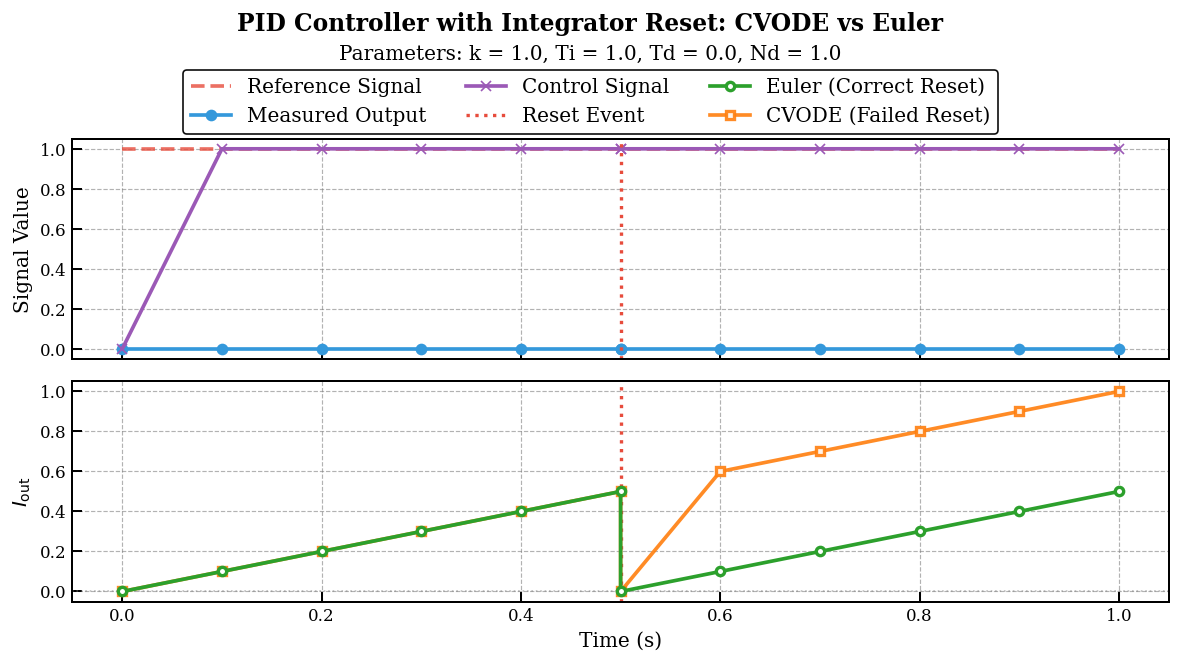

In [49]:
# Plot results - Comparison of CVODE vs Euler integrator reset behavior
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Find reset time (where there's a duplicate time value)
reset_idx = 5  # Based on i=4, after 5 steps
reset_time = 0.5

fig.suptitle('PID Controller with Integrator Reset: CVODE vs Euler', fontweight='bold', fontsize=14, y=1.10)
fig.text(0.5, 1.02, f'Parameters: k = {parameters["k"]}, Ti = {parameters["Ti"]}, Td = {parameters["Td"]}, Nd = {parameters["Nd"]}', 
         ha='center', fontsize=12)

# Top subplot: Control signal
ref_signal = ax1.plot(t_values, ref * np.ones_like(t_values), '--', label='Reference Signal', 
         color='#E74C3C', alpha=0.8)
measured_output_signal = ax1.plot(t_values, y * np.ones_like(t_values), '-o', label='Measured Output', 
         color='#3498DB')
control_signal = ax1.plot(t_values, u_values, '-x', label='Control Signal', 
         color='#9B59B6')
reset_signal = ax1.axvline(reset_time, color='#E74C3C', linestyle=':', linewidth=2, 
            label='Reset Event')
ax1.set_ylabel('Signal Value')
ax1.grid(True)

# Bottom subplot: Integrator outputs comparison
euler_signal = ax2.plot(t_values, I_out_values_euler, 'o-', markersize=5, 
         label='Euler (Correct Reset)', color='C2', markerfacecolor='white', 
         markeredgewidth=2, zorder=3)
cvode_signal = ax2.plot(t_values, I_out_values_cvode, 's-', markersize=5, 
         label='CVODE (Failed Reset)', color='C1', markerfacecolor='white', 
         markeredgewidth=2, zorder=2, alpha=0.9)
ax2.axvline(reset_time, color='#E74C3C', linestyle=':', linewidth=2)
ax2.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)

ax2.set_xlabel('Time (s)')
ax2.set_ylabel('$I_{\\mathrm{out}}$')
ax2.grid(True)
ax2.set_xlim(-0.05, max(t_values) + 0.05)

handles = [ref_signal[0], measured_output_signal[0], control_signal[0],reset_signal, euler_signal[0], cvode_signal[0]]
labels = [h.get_label() for h in handles]
fig.legend(handles, labels, loc='upper center', ncol=3, framealpha=0.95, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.savefig('../figures/Hybrid/test_3_reset.svg')
plt.show()

In [22]:
# Debug: Check individual PID terms at t=0.1
print("\nDebugging PID terms at t=0.1:")
print(f"ref = {ref}, y = {y}, error = {ref - y}")
print(f"Parameters: k={10}, Ti={0.05}, Td={0.6}, Nd={10}")
print(f"Expected P term: {ref - y}")
print(f"Expected I term (approx): {(ref - y) / 0.05 * 0.1:.4f}")
print(f"Control signal u at t=0.1: {u_values[1]:.4f}")
print(f"\nNote: Negative u suggests derivative term has negative transient")
print(f"or there's an initialization issue with the FMU.")


Debugging PID terms at t=0.1:
ref = 0.5, y = 0.0, error = 0.5
Parameters: k=10, Ti=0.05, Td=0.6, Nd=10
Expected P term: 0.5
Expected I term (approx): 1.0000
Control signal u at t=0.1: -1.0000

Note: Negative u suggests derivative term has negative transient
or there's an initialization issue with the FMU.
